Created by Nerea Barrio Cabezas

March, 2026

## Clasificación funcional de los efectores

Definimos las categorías funcionales de los efectores por medio de un diccionario y guardamos un archivo csv en el que haya dos columnas: la primera para el nombre del efector y la segunda para el grupo al que pertenece.

In [1]:
ef_classification = {
    'GTPasas': ['EspH', 'EspM', 'Map', 'EspT', 'NleO'],
    'Inflamación': ['NleB', 'NleC', 'NleE', 'EspO', 'NleK', 'LPS', 'EspS'],
    'Manipuladores de MAPK': ['NleD', 'NleL'],
    'Moduladores de Apoptosis': ['NleF', 'EspL', 'EspF', 'EspZ', 'NleH'],
    'Maquinaria T3SS': ['EscF', 'pORF8'],
    'Pedestal': ['Tir'],
    'Tráfico Vesicular': ['NleA', 'EspG']
}

De esta clasificación manual se han excluido los efectores que no aparecen en las interacciones positivas y los que aparecen solo una o dos veces.

In [2]:
# Numeramos los grupos para hacer más fácil trabajar con ellos
ef_groups = {
    'GTPasas': 0,
    'Inflamación': 1,
    'Manipuladores de MAPK': 2,
    'Moduladores de Apoptosis': 3,
    'Maquinaria T3SS': 4,
    'Pedestal': 5,
    'Tráfico Vesicular': 6
}

In [3]:
# Aplicamos esa numeración a los efectores 
efector_to_num = {}
for group, effector_list in ef_classification.items():
    num = ef_groups[group]
    for ef in effector_list:
        efector_to_num[ef] = num

efector_to_num

{'EspH': 0,
 'EspM': 0,
 'Map': 0,
 'EspT': 0,
 'NleO': 0,
 'NleB': 1,
 'NleC': 1,
 'NleE': 1,
 'EspO': 1,
 'NleK': 1,
 'LPS': 1,
 'EspS': 1,
 'NleD': 2,
 'NleL': 2,
 'NleF': 3,
 'EspL': 3,
 'EspF': 3,
 'EspZ': 3,
 'NleH': 3,
 'EscF': 4,
 'pORF8': 4,
 'Tir': 5,
 'NleA': 6,
 'EspG': 6}

In [4]:
# Hacemos lo mismo con los nombres de los grupos
group_name = {}
for group, effector_list in ef_classification.items():
    for ef in effector_list:
        group_name[ef] = group

group_name

{'EspH': 'GTPasas',
 'EspM': 'GTPasas',
 'Map': 'GTPasas',
 'EspT': 'GTPasas',
 'NleO': 'GTPasas',
 'NleB': 'Inflamación',
 'NleC': 'Inflamación',
 'NleE': 'Inflamación',
 'EspO': 'Inflamación',
 'NleK': 'Inflamación',
 'LPS': 'Inflamación',
 'EspS': 'Inflamación',
 'NleD': 'Manipuladores de MAPK',
 'NleL': 'Manipuladores de MAPK',
 'NleF': 'Moduladores de Apoptosis',
 'EspL': 'Moduladores de Apoptosis',
 'EspF': 'Moduladores de Apoptosis',
 'EspZ': 'Moduladores de Apoptosis',
 'NleH': 'Moduladores de Apoptosis',
 'EscF': 'Maquinaria T3SS',
 'pORF8': 'Maquinaria T3SS',
 'Tir': 'Pedestal',
 'NleA': 'Tráfico Vesicular',
 'EspG': 'Tráfico Vesicular'}

Guardamos la lista de efectores y el grupo al que pertenecen en un csv.

In [5]:
import pandas as pd

interactions = pd.read_csv("Interacciones_EffectorProteina_LiteratureOnly_Ordenadas_NleG.csv")
df_effectors = interactions[["Effector"]].drop_duplicates().reset_index(drop=True)
df_effectors["effector_group"] = df_effectors["Effector"].map(efector_to_num).apply(
    lambda x: f"Cluster {int(x)}" if pd.notna(x) else "-")
df_effectors["group_name"] = df_effectors["Effector"].map(group_name)

In [6]:
df_effectors

,Effector,effector_group,group_name
0,EspL,Cluster 3,Moduladores de Apoptosis
1,NleB,Cluster 1,Inflamación
2,NleA,Cluster 6,Tráfico Vesicular
3,NleC,Cluster 1,Inflamación
4,NleD,Cluster 2,Manipuladores de MAPK
5,NleE,Cluster 1,Inflamación
6,EspF,Cluster 3,Moduladores de Apoptosis
7,EspG,Cluster 6,Tráfico Vesicular
8,EspH,Cluster 0,GTPasas
9,EscF,Cluster 4,Maquinaria T3SS


In [7]:
df_effectors.to_csv("effector_groups_function.csv", index=False)
print("\nGuardado en effector_groups_function.csv")


Guardado en effector_groups_function.csv


Hacemos una representación visual más intuitiva de cómo quedan los grupos.

In [8]:
#!pip install networkx

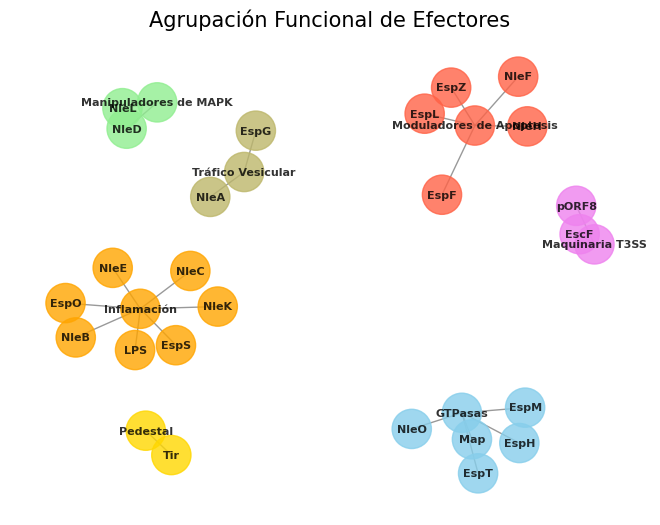

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.Graph()

colors_nodes = []
list_colors = ['skyblue', 'orange', 'lightgreen', 'tomato', 'violet', 'gold', 'darkkhaki']

for i, (group, members) in enumerate(ef_classification.items()):
    color = list_colors[i % len(list_colors)]
    
    # Añadimos el nodo del grupo (el centro)
    G.add_node(group, color=color, is_center=True)
    colors_nodes.append(color)
    
    # Añadimos los miembros y creamos la conexión (arista)
    for member in members:
        G.add_node(member, color=color, is_center=False)
        G.add_edge(group, member)
        colors_nodes.append(color)

pos = {}
n_groups = len(ef_classification)
radius = 70  # Radio del círculo donde irán los centros de los grupos

for i, (group, members) in enumerate(ef_classification.items()):
    # Calculamos la posición del centro del grupo en un círculo
    angle = 2 * np.pi * i / n_groups
    center_x = radius * np.cos(angle)
    center_y = radius * np.sin(angle)
    pos[group] = np.array([center_x, center_y])
    
    # Para los miembros, los dispersamos un poco alrededor de su centro
    # Creamos un pequeño subgrafo para cada grupo para usar spring_layout localmente
    subgrafo = G.subgraph([group] + members)
    # k controla qué tan dispersos están los miembros del centro
    pos_local = nx.spring_layout(subgrafo, center=pos[group], k=0.5, seed=42)
    pos.update(pos_local)

node_colors = [G.nodes[n]['color'] for n in G.nodes()]
node_sizes = [1500 if G.nodes[n].get('is_center') else 200 for n in G.nodes()]
    
# Configurar el diseño (Layout)
# 'spring_layout' hace que los grupos se repelan entre sí y se vean como nubes
plt.figure()
pos = nx.spring_layout(G, k=0.4, iterations=50) 

# 5. Dibujar
nx.draw(G, pos, 
        with_labels=True, 
        node_color=colors_nodes, 
        node_size=800, 
        edge_color='gray', 
        alpha=0.8,
        font_weight='bold',
        font_size=8)

plt.title("Agrupación Funcional de Efectores", fontsize=15)
plt.savefig("agrupacion_funcional_efectores.png", dpi=300)
plt.show()